# 3. Planetary–topographic regime switching with depth

Regimes use a 2:1 threshold. The primary result is the fraction of matched snapshots whose depth-following classification differs from the shallow classification.

In [5]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

HERE = Path.cwd().resolve()
ANALYSIS_ROOT = next((p for p in (HERE, *HERE.parents) if (p / "seacofs_tilt_tools.py").exists()), None)
if ANALYSIS_ROOT is None:
    raise FileNotFoundError("Run inside seacofs_eddy_tilt_analysis or one of its subfolders")
if str(ANALYSIS_ROOT) not in sys.path:
    sys.path.insert(0, str(ANALYSIS_ROOT))
if str(HERE) not in sys.path:
    sys.path.insert(0, str(HERE))

import seacofs_tilt_tools as tilt
import depth_pv_tools as dpt

sns.set_theme(style="whitegrid", context="notebook")
DOMINANCE_FACTOR = 2.0
TARGET_DEPTHS_M = (0, 200, 500, 700, 1000)
MIN_TILT_KM = 5.0
FIGSIZE = (7,4)

depth_df = tilt.add_pv_gradient_terms(source="depth")
snapshot_df = tilt.add_pv_gradient_terms(source="depth_snapshot")
dpt.validate_depth_tables(depth_df, snapshot_df)
DEPTHS = dpt.nearest_cached_depths(depth_df, TARGET_DEPTHS_M)
comparison = dpt.add_surface_differences(depth_df, DOMINANCE_FACTOR)
matched = dpt.matched_depth_rows(comparison, DEPTHS)
palette = {"AE": "#c44e52", "CE": "#4c72b0"}
depth_cmap = plt.get_cmap("viridis")
depth_colours = dict(zip(DEPTHS, depth_cmap(np.linspace(.08, .92, len(DEPTHS)))))
depth_labels = {z: f"{z:g} m" for z in DEPTHS}


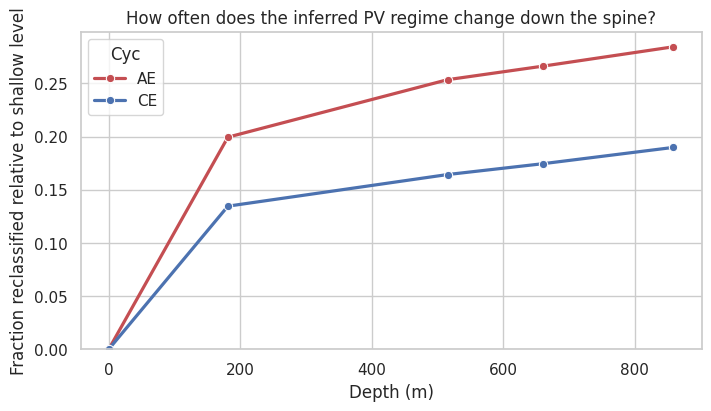

In [6]:
fraction = (matched.groupby(["Cyc", "Depth"], observed=True).regime_changed.mean().reset_index())
fig, ax = plt.subplots(figsize=FIGSIZE, constrained_layout=True)
sns.lineplot(data=fraction, x="Depth", y="regime_changed", hue="Cyc", palette=palette, marker="o", lw=2.3, ax=ax)
ax.set(ylabel="Fraction reclassified relative to shallow level", xlabel="Depth (m)", ylim=(0, None), title="How often does the inferred PV regime change down the spine?")
plt.show()

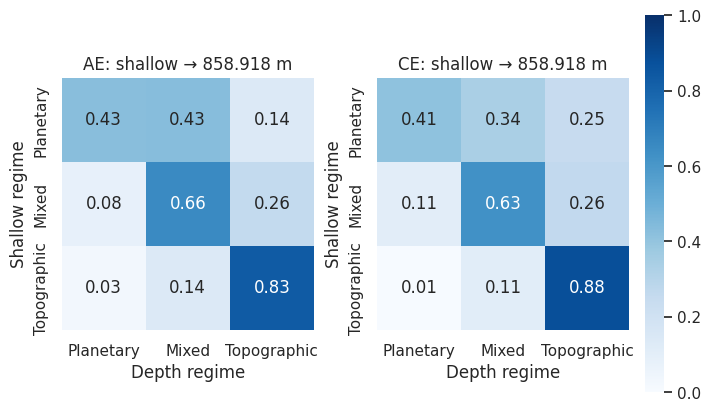

In [7]:
deep = DEPTHS[-1]
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE, constrained_layout=True)
for ax, cyc in zip(axes, ["AE", "CE"]):
    matrix = dpt.regime_transition_matrix(matched, deep, cyc)
    sns.heatmap(matrix, vmin=0, vmax=1, cmap="Blues", annot=True, fmt=".2f", square=True, ax=ax, cbar=cyc=="CE")
    ax.set(title=f"{cyc}: shallow → {deep:g} m", xlabel="Depth regime", ylabel="Shallow regime")
plt.show()

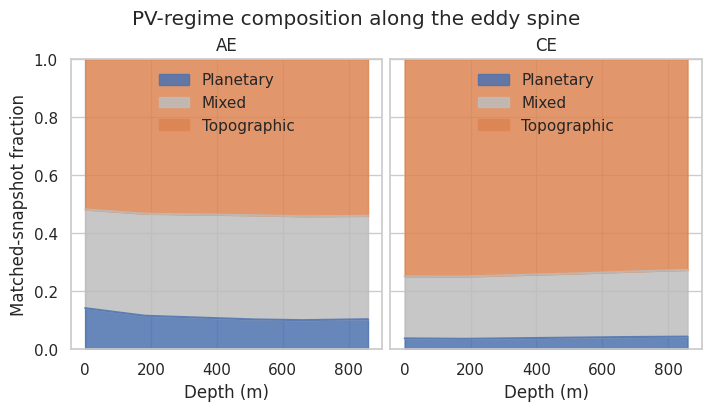

In [8]:
composition = (matched.groupby(["Cyc", "Depth", "regime"], observed=False).size().rename("n").reset_index())
composition["fraction"] = composition.n / composition.groupby(["Cyc", "Depth"]).n.transform("sum")
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE, sharey=True, constrained_layout=True)
regime_colours = {"Planetary":"#4c72b0", "Mixed":"#bdbdbd", "Topographic":"#dd8452"}
for ax, cyc in zip(axes, ["AE", "CE"]):
    pivot = composition[composition.Cyc.eq(cyc)].pivot(index="Depth", columns="regime", values="fraction").fillna(0)
    pivot.plot.area(ax=ax, color=[regime_colours[c] for c in pivot.columns], alpha=.85)
    ax.set(title=cyc, xlabel="Depth (m)", ylabel="Matched-snapshot fraction", ylim=(0,1)); ax.legend(frameon=False)
fig.suptitle("PV-regime composition along the eddy spine")
plt.show()